In [8]:
from plot_results import load_run
import torch

In [11]:
import os, sys
sys.path.append('../src/')
import viz

In [6]:
src_dir_name = "gridsearch__hardcoded__2026-04-23--10-55-14/n_steps_decay=1500__layers=128_128_128_128/ll_ode/"
model_1, pde_model, score_sde_model, args, losses, l2_errs, device, model_s = load_run(src_dir_name)
src_dir_name = "gridsearch__hardcoded__2026-04-23--10-55-14/n_steps_decay=6000__layers=128_128_128_128/ll_ode/"
model_2, pde_model, score_sde_model, args, losses, l2_errs, device, model_s = load_run(src_dir_name)

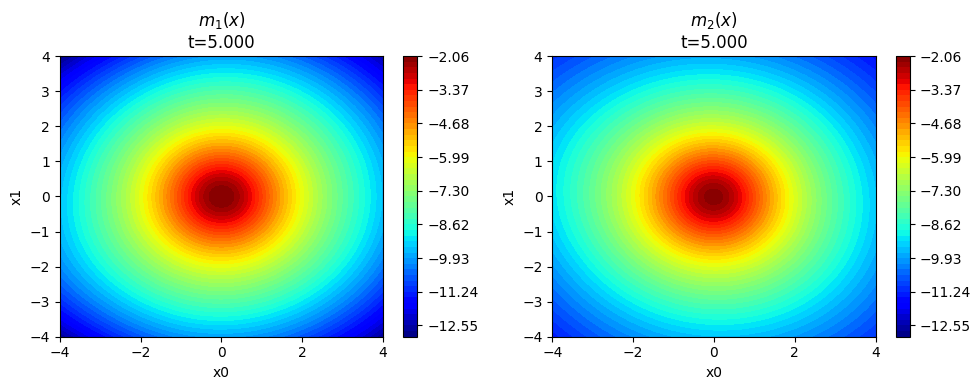

Pre-computing global color ranges...


/home/antos_j/diploma_sketchbook/PINN/case1_OrnsteinUhlenbeck/../src/viz.py:241: UserWarning: Adding colorbar to a different Figure <Figure size 1000x400 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, cax=cbar.ax)


<Figure size 640x480 with 0 Axes>

In [15]:
d = 4
L = 4.0
T = 5.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.0*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}

model_fn_1 = viz.wrapp_model(model_1)
model_fn_2 = viz.wrapp_model(model_2)
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('m1', title=r"$m_1(x)$").heatmap(model_fn_1)
plotter.add_panel('m2', title=r"$m_2(x)$").heatmap(model_fn_2)
#plotter.show_plot(t_val=5.0)
plotter.show_plot(t_val=5.0, cbar={"m2": "linked:m1"})
#plotter.show_animation(cbar='dynamic', num_frames=30, fps=5, t_end=T)
plotter.show_animation(cbar={"m2": "linked:m1"}, num_frames=30, fps=5, t_end=T)